In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\palla\Downloads\Zomoato project\Zomoato project\Zomato-data.csv", encoding="unicode_escape")
df


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [12]:
df.shape

(148, 7)

In [13]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [15]:
print(df.dtypes)


name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object


In [20]:
df.isnull().sum() 


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [11]:
df['rate']=(df['rate']
             .str.replace('/5',' ',regex=False)
            .replace('NEW',np.nan)
           .replace('-',np.nan)
           .astype(float))


In [76]:
print(df.dtypes)

name                            object
online_order                    object
book_table                      object
rate                           float64
votes                            int64
approx_cost(for two people)      int64
listed_in(type)                 object
dtype: object


In [26]:
df.info


<bound method DataFrame.info of                       name online_order book_table  rate  votes  \
0                    Jalsa          Yes        Yes   4.1    775   
1           Spice Elephant          Yes         No   4.1    787   
2          San Churro Cafe          Yes         No   3.8    918   
3    Addhuri Udupi Bhojana           No         No   3.7     88   
4            Grand Village           No         No   3.8    166   
..                     ...          ...        ...   ...    ...   
143       Melting Melodies           No         No   3.3      0   
144        New Indraprasta           No         No   3.3      0   
145           Anna Kuteera          Yes         No   4.0    771   
146                 Darbar           No         No   3.0     98   
147          Vijayalakshmi          Yes         No   3.9     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2         

In [28]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


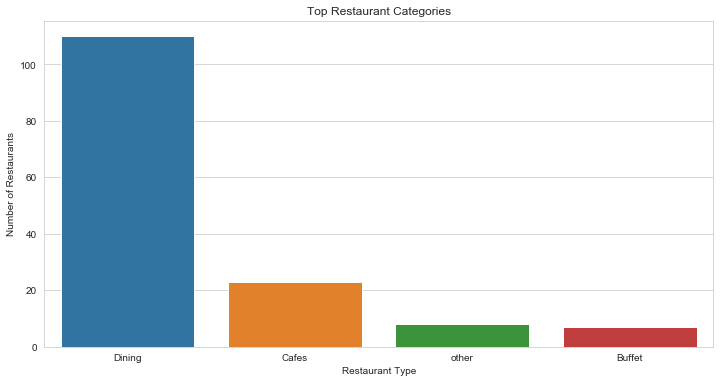

In [6]:
category_count= (df['listed_in(type)'].value_counts())
plt.figure(figsize=(12, 6))
sns.barplot(  y=category_count.values,x=category_count.index)
sns.set_style('whitegrid')
plt.title('Top Restaurant Categories')
plt.ylabel('Number of Restaurants')
plt.xlabel('Restaurant Type')
plt.savefig('downloads/top_restaurant_categories.png')
plt.show()

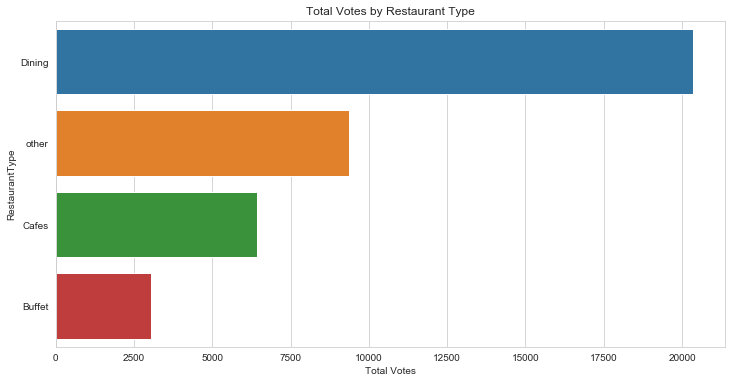

In [7]:
votes=(df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False))
plt.figure(figsize=(12, 6))
sns.barplot(x=votes.values,y=votes.index)
plt.title('Total Votes by Restaurant Type')
plt.xlabel('Total Votes')
plt.ylabel('RestaurantType')
plt.savefig('downloads/votes_by_type.png')
plt.show()

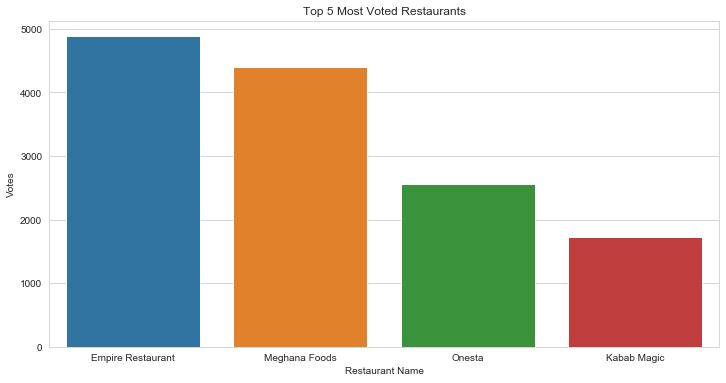

In [8]:
plt.figure(figsize=(12, 6))

top_restaurants = (
    df.nlargest(5, 'votes')[['name', 'votes']]
)

sns.barplot(
    data=top_restaurants,
    y='votes',
    x='name'
)

plt.title('Top 5 Most Voted Restaurants')
plt.ylabel('Votes')
plt.xlabel('Restaurant Name')
plt.savefig('downloads/Top 5 Most Voted Restaurants.png')

plt.show()

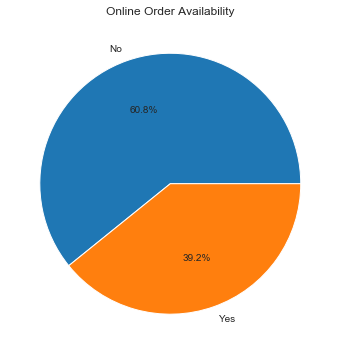

In [9]:
online_orders=(df['online_order'].value_counts())
plt.figure(figsize=(10,6))
plt.pie(online_orders.values,
labels=online_orders.index,
autopct='%1.1f%%')

plt.title('Online Order Availability')
plt.savefig('downloads/online_order_availability.png')

plt.show()

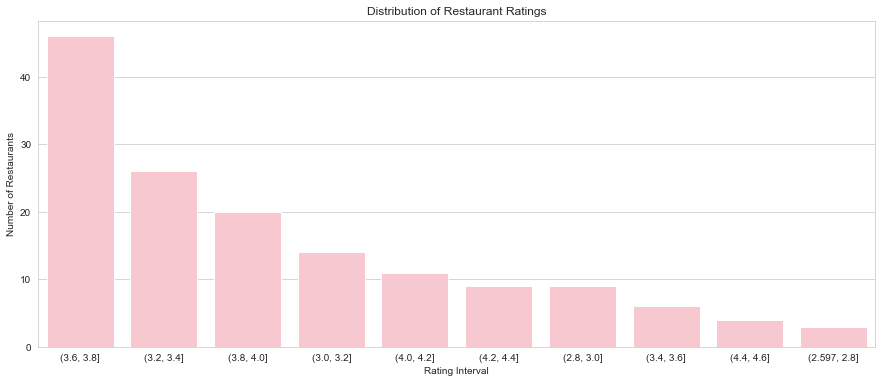

In [12]:

counts = df['rate'].dropna().value_counts(bins=10)

plt.figure(figsize=(15, 6))

sns.barplot(
    x=counts.index,  
    y=counts.values,
    color='pink'            
)


plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating Interval')
plt.ylabel('Number of Restaurants')
plt.savefig('downloads/Distribution of Restaurant Ratings.png')
plt.show()



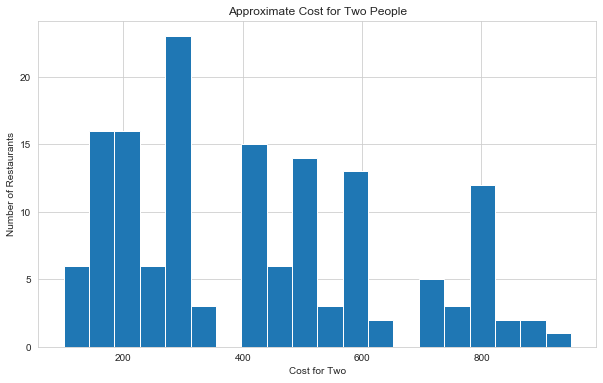

In [14]:


plt.figure(figsize=(10, 6))

plt.hist(
    df['approx_cost(for two people)'].dropna(),
    bins=20
)

plt.title('Approximate Cost for Two People')
plt.xlabel('Cost for Two')
plt.ylabel('Number of Restaurants')
plt.savefig('downloads/cost for 2 people.png')
plt.show()


plt.show()

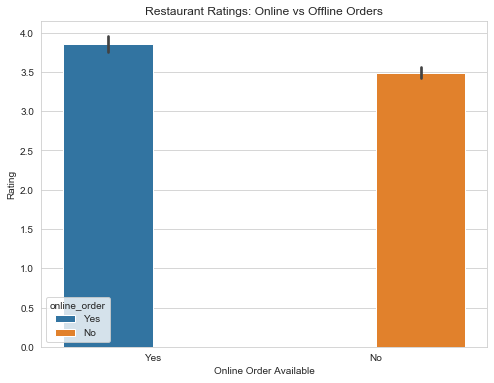

In [15]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df,
    x='online_order',
    y='rate',
    hue='online_order'
)

plt.title('Restaurant Ratings: Online vs Offline Orders')
plt.xlabel('Online Order Available')
plt.ylabel('Rating')
plt.savefig('downloads/online vs offline orders.png')
plt.show()

plt.show()

In [55]:

df['rate'] = (
    df['rate']
    .astype(str)
    .str.replace('/5', '', regex=False)
    .replace('NEW', np.nan)
    .replace('-', np.nan)
)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')